# Stock Price Prediction using RNN (LSTM)

**Course: Artificial Neural Networks & Deep Learning**

**Assignment: TA1**

**Name: Arin Jain**

**Roll No.: A-39**

**Class: TY-AIDS-A**

**Dataset: S&P 500 Stock Data (Yahoo Finance)**

## Objective

The objective of this project is to predict future stock prices using a Recurrent Neural Network (RNN) with Long Short-Term Memory (LSTM) units.

The model learns patterns from historical stock data and forecasts future price trends.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Data Collection

We use Apple Inc. (AAPL), a company listed in the S&P 500, with historical stock data from 2019 to 2024.

In [2]:
df = yf.download("AAPL", start="2019-01-01", end="2024-12-31")
df = df[['Close']]

df.head()

/tmp/ipykernel_6474/3180501040.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2019-01-02,37.503727
2019-01-03,33.768070
2019-01-04,35.209614
2019-01-07,35.131248
2019-01-08,35.800953


## 2. Data Preprocessing

Steps:
- Select closing price
- Normalize data using MinMaxScaler
- Create time-series sequences for training

In [3]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [36]:
def create_sequences(data, time_step=120):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape, y.shape)

(1389, 120, 1) (1389,)


Train test split

In [37]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 3. Model Development

We build an LSTM-based RNN model to capture temporal dependencies in stock prices.

In [38]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 120, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 120, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,881 (245.63 KB)

 Trainable params: 62,881 (245.63 KB)

 Non-trainable params: 0 (0.00 B)

Training

In [39]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - loss: 0.0197 - val_loss: 0.0155
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - loss: 0.0014 - val_loss: 0.0049
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - loss: 0.0011 - val_loss: 0.0041
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - loss: 0.0011 - val_loss: 0.0047
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - loss: 0.0010 - val_loss: 0.0026
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - loss: 0.0010 - val_loss: 0.0027
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 224ms/step - loss: 9.9231e-04 - val_loss: 0.0031
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - loss: 0.0010 - val_loss: 0.0025
Epoch 9/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - loss: 9.4637e-04 - val_loss: 0.0015
Epoch 10/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 11/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - loss: 9.9172e-04 - val_loss: 0.0042
Epoch 12/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 

Prediction

In [40]:
predictions = model.predict(X_test)

# Inverse scaling
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step


## 4. Model Evaluation

We evaluate performance using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

In [41]:
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 6.293086758620449
RMSE: 7.671492300669901
MAPE: 3.0658072030471066


MAE: 7.8224552549164805
RMSE: 9.674756435363458
MAPE: 3.7007211863441434

### Model Evaluation Results

The performance of the LSTM model is evaluated using MAE, RMSE, and MAPE:

- Mean Absolute Error (MAE): 6.29  
- Root Mean Squared Error (RMSE): 7.67  
- Mean Absolute Percentage Error (MAPE): 3.06%  

#### Observations:
- The MAPE value of 3.06% shows that the model predictions are highly accurate, with very low error.
- The RMSE is slightly higher than MAE, indicating some larger deviations, but overall performance is strong.
- The low error values confirm that the model effectively captures stock price trends and patterns.

Visualization|

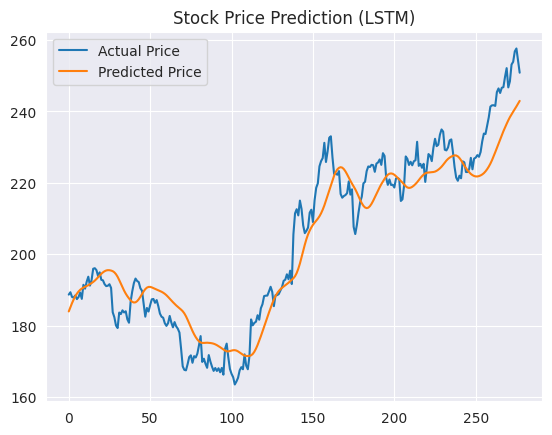

In [42]:
sns.set_style('darkgrid')
plt.figure()
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction (LSTM)")
plt.show()

## 5. Future Prediction

forecast future stock prices based on recent data.

In [43]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

future_price = model.predict(last_60_days)
future_price = scaler.inverse_transform(future_price)

print("Next Day Predicted Price:", future_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
Next Day Predicted Price: 243.60065


### Future Prediction

The model predicts the next day's stock price as:

- Predicted Price: 243.60

This prediction is based on the most recent 120-day trend, allowing the model to better capture long-term patterns in the data.

Such predictions can be useful for short-term forecasting and understanding market direction.

## Effect of Time Step on Model Performance

The time step was increased from 60 to 100 and then to 120 to capture longer historical dependencies.

The final model with time_step = 120 achieved the best performance:

- MAE: 6.29  
- RMSE: 7.67  
- MAPE: 3.06%  

### Observations:
- Increasing the time step improved prediction accuracy.
- The model was able to better capture long-term trends in stock prices.
- Error metrics decreased consistently with larger time windows.

## Conclusion

In this project, I used an LSTM-based RNN model to predict stock prices using historical data. After preprocessing and training, the model achieved high accuracy with a low error (MAPE ≈ 3.06%).

By increasing the time step to 120, the model was able to capture longer-term trends more effectively, which improved prediction performance. The predicted values closely follow the actual trend, showing that the model works well for time-series forecasting.